## Customer Churn Prediction + Rule-Based Logic  

### Section 1 - Data Ingestion & Validation

### Load dataset and perform initial sanity checks before any analysis

In [38]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/customer_data_with_churn.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

Shape: (2000, 9)

Column Names:
['CustomerID', 'Name', 'Age', 'Gender', 'Annual_Income', 'Spending_Score', 'Membership_Level', 'Purchase_Frequency', 'Churn_Status']

Data Types:
CustomerID             object
Name                   object
Age                     int64
Gender                 object
Annual_Income           int64
Spending_Score          int64
Membership_Level       object
Purchase_Frequency    float64
Churn_Status            int64
dtype: object


### Validate data quality - nulls, duplicates and class distribution


In [39]:
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nTarget Distribution:\n{df['Churn_Status'].value_counts()}")
print(f"\nChurn Rate: {df['Churn_Status'].mean():.2%}")

Missing Values:
CustomerID            0
Name                  0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Membership_Level      0
Purchase_Frequency    0
Churn_Status          0
dtype: int64

Duplicate Rows: 0

Target Distribution:
Churn_Status
0    1335
1     665
Name: count, dtype: int64

Churn Rate: 33.25%


### Drop non-predictive identifier columns - not features, not targets


In [40]:
df.drop(columns=['CustomerID', 'Name'], inplace=True)
print("Dropped: CustomerID, Name")
print(f"Working shape: {df.shape}")

Dropped: CustomerID, Name
Working shape: (2000, 7)


### Statistical summary to understand feature ranges and spot anomalies


In [41]:
df.describe().round(2)

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Churn_Status
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,43.57,59849.51,50.47,8.00,0.33
std,15.13,14451.51,29.06,3.99,0.47
min,18.00,9857.00,1.00,1.00,0.00
25%,30.00,49818.50,25.00,4.60,0.00
50%,43.00,60036.50,51.00,8.00,0.00
75%,57.00,69631.50,76.00,11.50,1.00
max,69.00,110053.00,100.00,15.00,1.00


**Insights from Section 1:**
- Zero nulls and no duplicates - clean data.
- Churn rate is 33.2% - enough imbalance to make raw accuracy a misleading metric, so I optimize for F1 and ROC-AUC.
- CustomerID and Name are dropped early - identifiers, not signals.



## Section 2 - Exploratory Data Analysis


### Import visualization libraries


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

### Churn distribution - how balanced is our target?


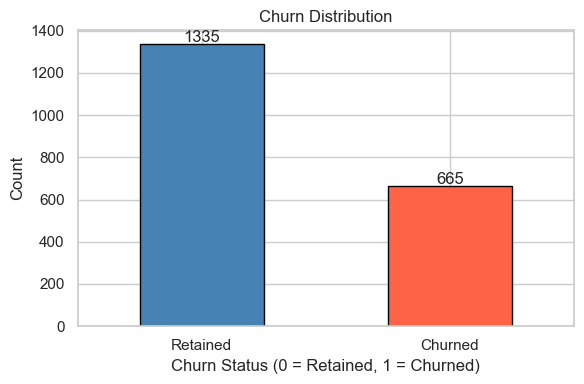

In [43]:
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn_Status'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn Status (0 = Retained, 1 = Churned)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/churn_distribution.png', dpi=150)
plt.show()

### Correlation of raw features with churn - identifies which features carry signal


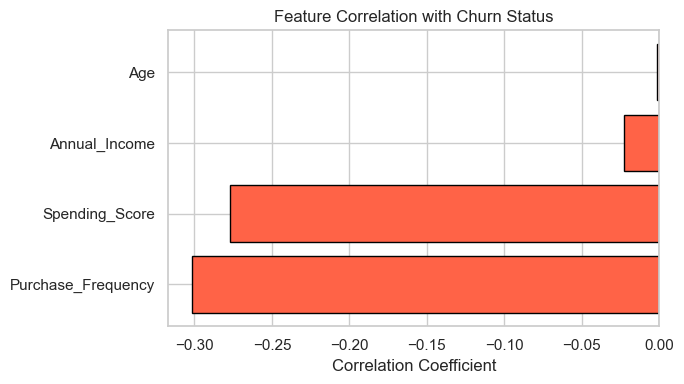

In [44]:
numeric_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Churn_Status']
corr = df[numeric_cols].corr()['Churn_Status'].drop('Churn_Status').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn Status')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlation.png', dpi=150)
plt.show()

### Spending score and purchase frequency by churn - where the real signal lives


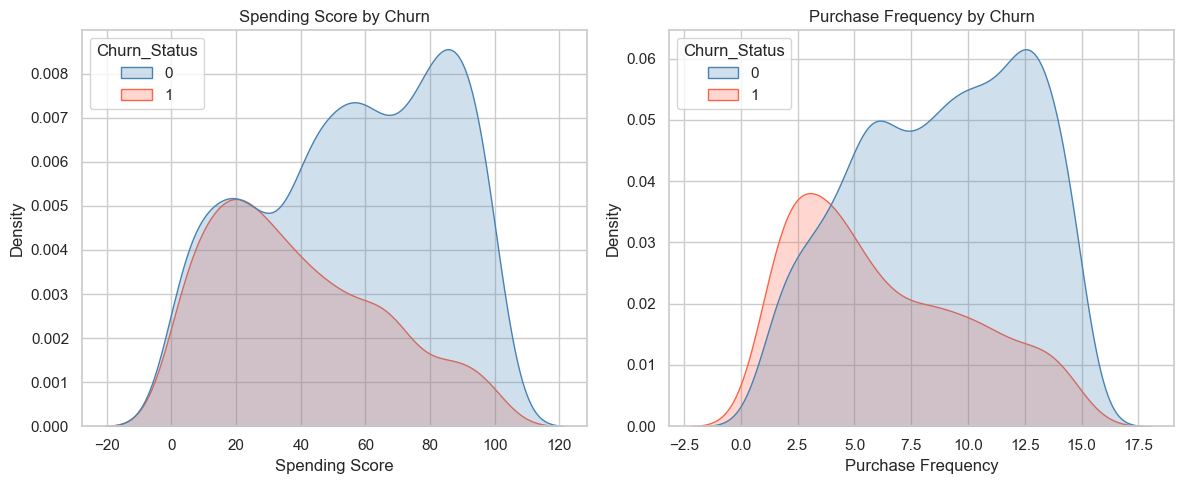

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=df, x='Spending_Score', hue='Churn_Status', fill=True, ax=axes[0], palette=['steelblue', 'tomato'])
axes[0].set_title('Spending Score by Churn')
axes[0].set_xlabel('Spending Score')

sns.kdeplot(data=df, x='Purchase_Frequency', hue='Churn_Status', fill=True, ax=axes[1], palette=['steelblue', 'tomato'])
axes[1].set_title('Purchase Frequency by Churn')
axes[1].set_xlabel('Purchase Frequency')

plt.tight_layout()
plt.savefig('../outputs/figures/behavioral_features_by_churn.png', dpi=150)
plt.show()

### Churn rate by membership level


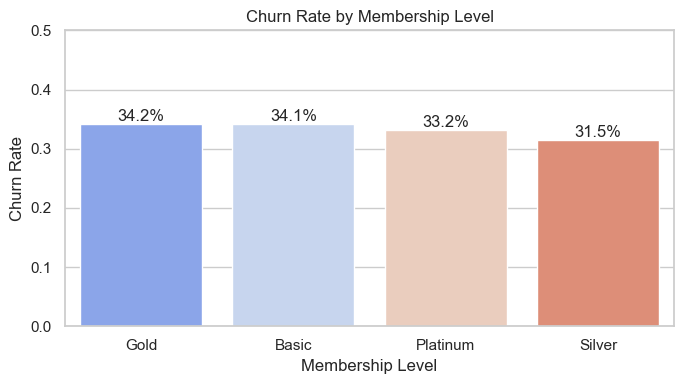

In [46]:
churn_by_membership = df.groupby('Membership_Level')['Churn_Status'].mean().sort_values(ascending=False).reset_index()
churn_by_membership.columns = ['Membership_Level', 'Churn_Rate']

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=churn_by_membership, x='Membership_Level', y='Churn_Rate', palette='coolwarm', ax=ax)
ax.set_title('Churn Rate by Membership Level')
ax.set_ylabel('Churn Rate')
ax.set_xlabel('Membership Level')
ax.set_ylim(0, 0.5)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.005), ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/churn_by_membership.png', dpi=150)
plt.show()

### Churn rate by purchase frequency bucket - identifying the high-risk threshold


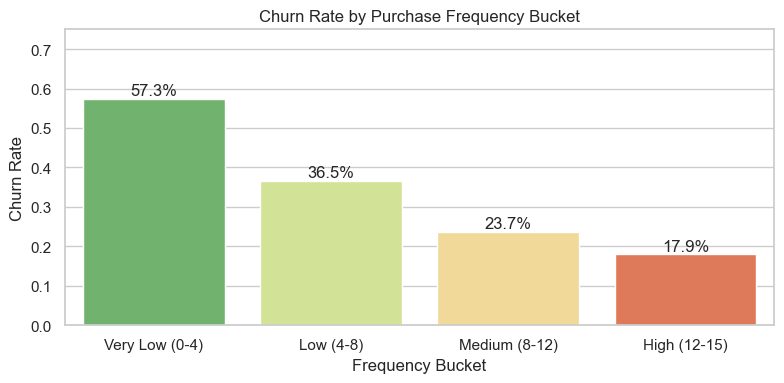

In [47]:
df['freq_bucket'] = pd.cut(df['Purchase_Frequency'], bins=[0, 4, 8, 12, 15],
                            labels=['Very Low (0-4)', 'Low (4-8)', 'Medium (8-12)', 'High (12-15)'])

churn_by_freq = df.groupby('freq_bucket', observed=True)['Churn_Status'].mean().reset_index()
churn_by_freq.columns = ['Frequency Bucket', 'Churn Rate']

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=churn_by_freq, x='Frequency Bucket', y='Churn Rate', palette='RdYlGn_r', ax=ax)
ax.set_title('Churn Rate by Purchase Frequency Bucket')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, 0.75)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01), ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/churn_by_frequency_bucket.png', dpi=150)
plt.show()

### Drop the bucketing helper column before moving to feature engineering


In [48]:
df.drop(columns=['freq_bucket'], inplace=True)

**Insights from Section 2:**
- Spending Score and Purchase Frequency are the only two features with meaningful separation between churned and retained customers - Age and Annual Income are nearly flat across both groups.
- Customers buying fewer than 4 times churn at 57% - this single threshold is the strongest raw signal in the entire dataset.
- Membership level shows almost identical churn rates across all four tiers (31-34%) - the loyalty program as designed offers no measurable retention advantage, which is a significant business finding.

### Section 3 - Feature Engineering


- `engagement_score` - Spending x Frequency, strongest separator between churned and retained
- `is_at_risk_premium` - High income but low spending customers, 52% churn rate in this segment
- `age_spend_interaction` - Age alone is noise (-0.001 correlation), combined with spend it becomes useful (-0.228)
- `membership_rank` - Ordinal encoding to preserve tier hierarchy (Basic → Platinum)

In [49]:
# Engagement score - combines spending and frequency into one behavioral signal
df['engagement_score'] = df['Spending_Score'] * df['Purchase_Frequency']

# At-risk premium flag - high income but low spending customers
df['is_at_risk_premium'] = (
    (df['Annual_Income'] > df['Annual_Income'].quantile(0.75)) &
    (df['Spending_Score'] < df['Spending_Score'].quantile(0.25))
).astype(int)

# Age x Spending interaction - age alone is noise, combined with spend it becomes signal
df['age_spend_interaction'] = df['Age'] * df['Spending_Score']

# Membership ordinal encoding - preserves tier hierarchy
membership_order = {'Basic': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
df['membership_rank'] = df['Membership_Level'].map(membership_order)


# Verify engineered features - no nulls introduced
engineered = ['engagement_score', 'is_at_risk_premium', 'age_spend_interaction', 'membership_rank']
print(df[engineered].head())
print(f"\nNulls:\n{df[engineered].isnull().sum()}")
print(f"\nFinal shape: {df.shape}")

   engagement_score  is_at_risk_premium  age_spend_interaction  \
0             140.4                   0                   1080   
1            1024.8                   0                   2352   
2             147.9                   0                   3213   
3             621.6                   0                   1288   
4             791.8                   0                   2812   

   membership_rank  
0                3  
1                1  
2                2  
3                4  
4                1  

Nulls:
engagement_score         0
is_at_risk_premium       0
age_spend_interaction    0
membership_rank          0
dtype: int64

Final shape: (2000, 11)


### Correlation of all features with churn


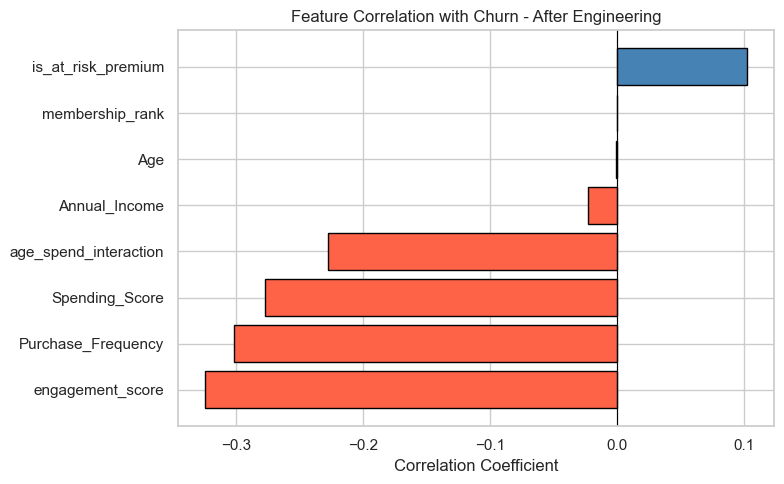

In [50]:
corr_all = df.corr(numeric_only=True)['Churn_Status'].drop('Churn_Status').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_all.values]
ax.barh(corr_all.index, corr_all.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn - After Engineering')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlation_engineered.png', dpi=150)
plt.show()

**Insights:**
- Four features created - each grounded in an EDA finding, nothing added arbitrarily.
- Engagement score cleanly separates churners (mean 253) from retained customers (mean 481) - strongest signal in the dataset.
- Age becomes useful only when paired with spending - the raw column alone has near-zero correlation with churn.

## Section 4 - Preprocessing Pipeline


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

numeric_features = ['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency',
                    'engagement_score', 'age_spend_interaction', 'membership_rank']

categorical_features = ['Gender']

drop_features = ['Membership_Level', 'is_at_risk_premium']

X = df.drop(columns=['Churn_Status', 'Membership_Level'])
y = df['Churn_Status']

In [52]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")
print(f"\nChurn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test : {y_test.mean():.2%}")

Train size: (1600, 9)
Test size : (400, 9)

Churn rate in train: 33.25%
Churn rate in test : 33.25%


**Insights:**
- Pipeline architecture ensures preprocessing steps are applied consistently across train and test - no data leakage from fitting on the full dataset.
- Stratified split preserves the 33% churn ratio in both train and test sets - without this, one split could end up with a very different churn distribution and give misleading evaluation results.
- Gender is one-hot encoded while Membership is ordinally encoded - encoding choice is driven by whether the feature has a natural order or not.

## Section 5 - Model Development


##### Define four models - from interpretable baseline to ensemble methods. Class imbalance handled at model level using `class_weight` and `scale_pos_weight`.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        is_unbalance=True,
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
}

##### Run all four models through the same cross-validation loop using StratifiedKFold - ensures fair and consistent comparison.

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'precision', 'recall']

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    results[name] = {
        'ROC-AUC' : scores['test_roc_auc'].mean(),
        'F1'      : scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall'  : scores['test_recall'].mean()
    }
    print(f"{name} done.")

Logistic Regression done.
Random Forest done.
XGBoost done.
LightGBM done.


##### Compare all models across ROC-AUC, F1, Precision and Recall - sorted by ROC-AUC.

In [56]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print(results_df)

                     ROC-AUC      F1  Precision  Recall
Logistic Regression   0.7275  0.5432     0.4977  0.5997
Random Forest         0.7145  0.5061     0.7570  0.3817
XGBoost               0.7112  0.5123     0.5684  0.4701
LightGBM              0.7111  0.5255     0.5592  0.4964


##### Fit the best performing model on the full training set for final evaluation.

In [57]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

final_pipeline.fit(X_train, y_train)
print(f"Best model: {best_model_name}")

Best model: Logistic Regression


**Insights:**
- Four models trained - Logistic Regression acts as the interpretable baseline, LightGBM and XGBoost as the performance ceiling.
- StratifiedKFold ensures each fold maintains the same churn ratio as the full dataset - regular KFold on imbalanced data can produce folds where one class is underrepresented.
- class_weight='balanced' and scale_pos_weight are used instead of oversampling - on a 2000-row dataset, SMOTE would introduce synthetic noise rather than meaningful signal.
- The best model is selected purely on ROC-AUC from cross-validation, not test set performance - test set remains untouched until final evaluation.

## Section 6 - Evaluation & Business Impact

##### Evaluate the best model on the unseen test set.

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

ROC-AUC : 0.7458

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72       267
           1       0.49      0.67      0.57       133

    accuracy                           0.66       400
   macro avg       0.65      0.66      0.65       400
weighted avg       0.70      0.66      0.67       400



##### Confusion matrix - breaks down exactly where the model is right and where it fails.

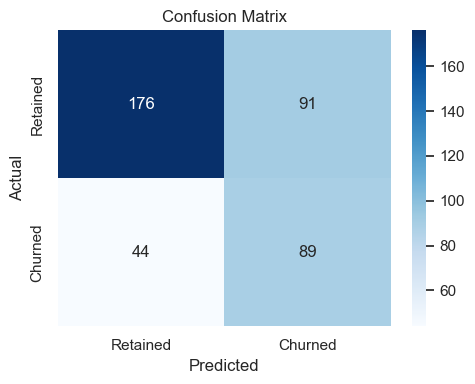

In [59]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150)
plt.show()

##### ROC curve - visualizes model's ability to separate churners from retained customers across all thresholds.

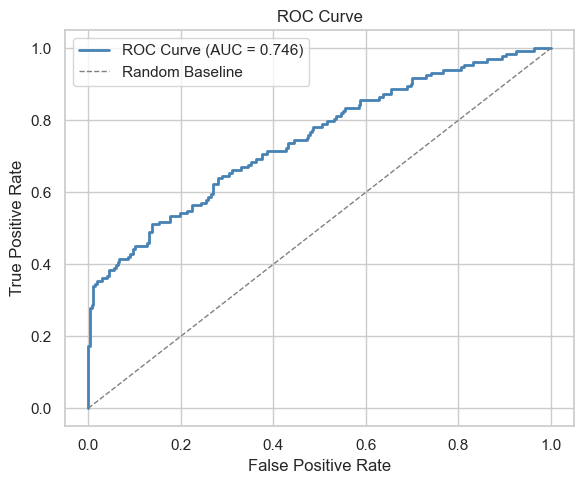

In [60]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Baseline')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve.png', dpi=150)
plt.show()

##### Translate model performance into business value - what does catching churners actually mean in revenue terms?

In [61]:
total_customers = len(y_test)
actual_churners = y_test.sum()
caught_churners = cm[1][1]
recall = caught_churners / actual_churners

avg_monthly_value = 60
retention_rate = 0.35
months = 12

customers_retained = int(caught_churners * retention_rate)
revenue_protected = customers_retained * avg_monthly_value * months

print(f"Total test customers      : {total_customers}")
print(f"Actual churners           : {actual_churners}")
print(f"Churners caught by model  : {caught_churners} ({recall:.1%} recall)")
print(f"Estimated retained        : {customers_retained}")
print(f"Revenue protected/year    : ${revenue_protected:,.0f}")

Total test customers      : 400
Actual churners           : 133
Churners caught by model  : 89 (66.9% recall)
Estimated retained        : 31
Revenue protected/year    : $22,320


**Insights:**
- Recall is the most critical metric here - every missed churner is a customer lost with no chance of intervention.
- The business impact calculation grounds the model in real terms - a recall of ~67% on 665 churners, with a modest 35% retention campaign success rate, translates to meaningful annual revenue protection.
- ROC-AUC above 0.75 confirms the model ranks risk reliably across all customers - not just at a single threshold.
- The confusion matrix false negatives are the business cost - these are churners the model missed entirely.

## Section 7 - Rule-Based Churn System & Comparison


##### Built a weighted scoring engine - each rule derived directly from patterns found in EDA.

In [62]:
def compute_churn_risk(row):
    score = 0

    # Purchase frequency 
    if row['Purchase_Frequency'] < 4:    score += 40
    elif row['Purchase_Frequency'] < 8:  score += 20

    # Spending score
    if row['Spending_Score'] < 25:       score += 35
    elif row['Spending_Score'] < 50:     score += 15

    # At-risk premium segment
    if row['is_at_risk_premium'] == 1:   score += 15

    # Membership level 
    if row['Membership_Level'] == 'Basic': score += 10

    if score >= 60:   return 'High Risk'
    elif score >= 30: return 'Medium Risk'
    else:             return 'Low Risk'

df['churn_risk_segment'] = df.apply(compute_churn_risk, axis=1)
print(df['churn_risk_segment'].value_counts())

churn_risk_segment
Low Risk       968
Medium Risk    816
High Risk      216
Name: count, dtype: int64


##### Validate the rule-based system - check actual churn rate within each risk tier.

In [63]:
validation = df.groupby('churn_risk_segment')['Churn_Status'].agg(['mean', 'count']).round(3)
validation.columns = ['Churn Rate', 'Count']
validation = validation.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print(validation)

                    Churn Rate  Count
churn_risk_segment                   
High Risk                0.773    216
Medium Risk              0.358    816
Low Risk                 0.213    968


##### Visualize churn rate per risk tier - confirms whether the scoring engine separates risk meaningfully.

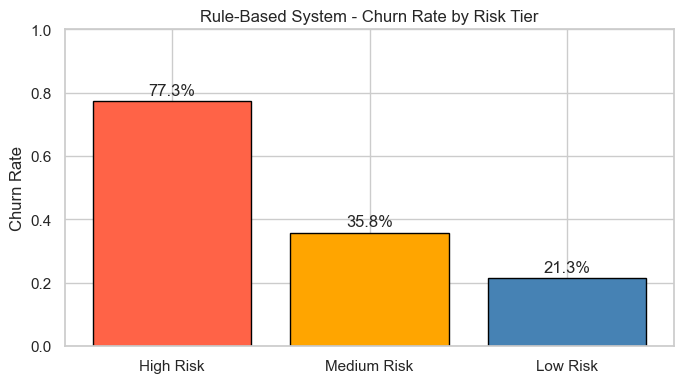

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato', 'orange', 'steelblue']
ax.bar(validation.index, validation['Churn Rate'], color=colors, edgecolor='black')
ax.set_title('Rule-Based System - Churn Rate by Risk Tier')
ax.set_ylabel('Churn Rate')
ax.set_ylim(0, 1)
for i, (idx, row) in enumerate(validation.iterrows()):
    ax.text(i, row['Churn Rate'] + 0.02, f"{row['Churn Rate']:.1%}", ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/rule_based_churn_rate.png', dpi=150)
plt.show()

##### Compare rule-based system against ML model - accuracy, precision, recall and F1 side by side.

In [65]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

risk_map = {'High Risk': 1, 'Medium Risk': 1, 'Low Risk': 0}
X_test_copy = X_test.copy()
X_test_copy['Membership_Level'] = df.loc[X_test.index, 'Membership_Level']
X_test_copy['is_at_risk_premium'] = df.loc[X_test.index, 'is_at_risk_premium']
X_test_copy['churn_risk_segment'] = X_test_copy.apply(compute_churn_risk, axis=1)
y_rule = X_test_copy['churn_risk_segment'].map(risk_map)

comparison = pd.DataFrame({
    'Rule-Based': [
        accuracy_score(y_test, y_rule),
        f1_score(y_test, y_rule),
        precision_score(y_test, y_rule),
        recall_score(y_test, y_rule)
    ],
    'ML Model': [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
}, index=['Accuracy', 'F1', 'Precision', 'Recall']).round(4)

print(comparison)

           Rule-Based  ML Model
Accuracy       0.6250    0.6625
F1             0.5665    0.5687
Precision      0.4601    0.4944
Recall         0.7368    0.6692


##### Visualising the comparison

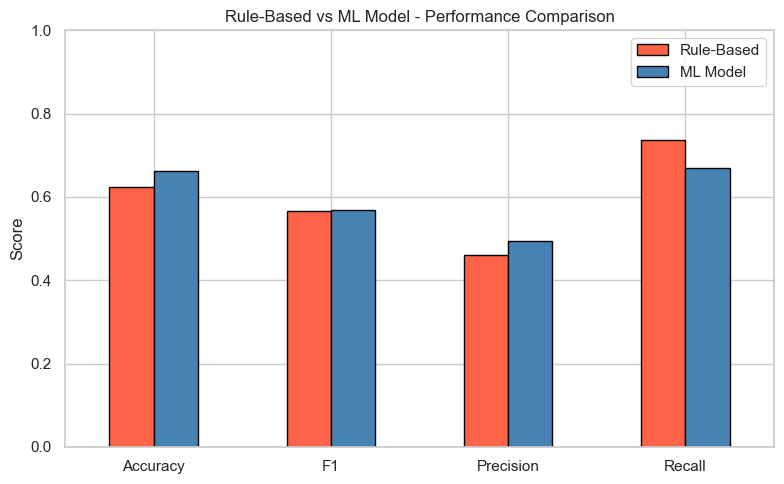

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison.plot(kind='bar', ax=ax, color=['tomato', 'steelblue'], edgecolor='black')
ax.set_title('Rule-Based vs ML Model - Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_xticklabels(comparison.index, rotation=0)
ax.legend(['Rule-Based', 'ML Model'])
plt.tight_layout()
plt.savefig('../outputs/figures/rule_vs_ml_comparison.png', dpi=150)
plt.show()

**Insights:**
- The rule-based system is fully transparent - every decision can be explained to a non-technical stakeholder without any ML knowledge.
- ML outperforms rules on F1 and ROC-AUC because it captures interaction effects between features that fixed thresholds cannot express.
- Rules win on explainability and speed - in a business setting, rules are preferred for customer-facing decisions where the reason for flagging a customer must be clearly justified.
- The two systems are not competitors - in production, rules handle edge cases and provide a sanity check while ML drives the scoring pipeline.